In [116]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
## general libraries
import pathlib
from rich.pretty import install, pprint

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

install(overflow=True)

In [166]:
cfg = pamir.utils.load_hydra_config(
    config_dir='../../src/pamir_mlpermafrost/conf', 
    config_name='jupyter')

2025-08-19 11:35:32 | WARNING  - Will pop `run_dir` since detected in Notebook and cant be resolved


In [167]:
data = cfg.data.training.load().loc[["S180_exp4", "N180_exp4"]]
data = data.reset_index().set_index(["y", "x"])

# Preprocess the data
data_X, data_y = cfg.preprocessing.training(data)

# Split the data into training and testing sets
train_X, test_X, train_y, test_y = cfg.preprocessing.train_test_split(
    data_X, data_y
)

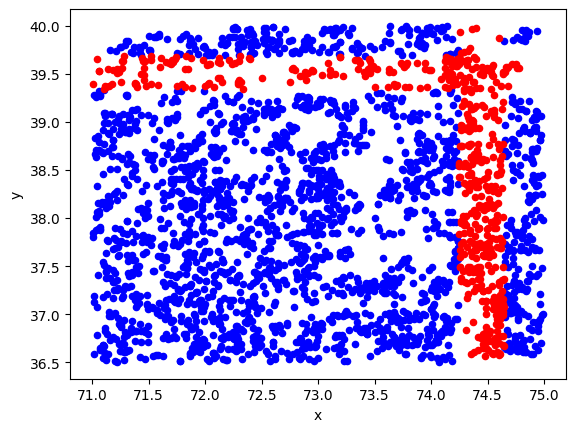

In [168]:
ax = train_X.reset_index().plot.scatter(x='x', y='y', c='b')
ax = test_X.reset_index().plot.scatter(x='x', y='y', c='r', ax=ax)

In [169]:
modelA = ngboost.NGBRegressor(n_estimators=100, verbose_eval=20, learning_rate=0.3)
modelA.fit(train_X, train_y)

test_yhat = modelA.predict(test_X)
metrics.r2_score(test_y, test_yhat)

[iter 0] loss=3.0300 val_loss=0.0000 scale=1.0000 norm=3.6020
[iter 20] loss=1.6124 val_loss=0.0000 scale=1.0000 norm=1.2699
[iter 40] loss=1.3869 val_loss=0.0000 scale=1.0000 norm=1.0943
[iter 60] loss=1.2404 val_loss=0.0000 scale=1.0000 norm=0.9889
[iter 80] loss=1.1234 val_loss=0.0000 scale=1.0000 norm=0.9122


0.8238289287148526

In [170]:
y_dists_avg, y_dists_std = modelA.pred_dist(test_X).params.values()
y_dists_avg = pd.Series(y_dists_avg, index=test_y.index).rename('average')
y_dists_std = pd.Series(y_dists_std, index=test_y.index).rename('stdev')
y_resid = abs(test_y - y_dists_avg).rename('residuals')

In [171]:
modelB = trees.ExtraTreesRegressor(n_estimators=50, n_jobs=-1, min_samples_split=4, min_samples_leaf=1)
# modelB = trees.HistGradientBoostingRegressor(max_iter=500)
modelB.fit(train_X, train_y)

train_yhat = modelB.predict(train_X)
test_yhat = modelB.predict(test_X)
metrics.r2_score(test_y, test_yhat), metrics.r2_score(train_y, train_yhat)

(0.8400705221152789, 0.9976222471169991)

In [172]:
if 0:
    predictors = cfg.data.inference.load().isel(x=slice(500, 2000), y=slice(-2000, -500))
    x_unprocessed = predictors.to_dataframe()
    x = cfg.preprocessing.inference(x_unprocessed)

In [173]:
mask = predictors.surface_index > 0

In [174]:
yhat, ystd = modelA.pred_dist(x).params.values()
yhat = pd.Series(yhat, index=x_unprocessed.index).rename('yhat')
ystd = pd.Series(ystd, index=x_unprocessed.index).rename('ystd')
yhat = pd.concat([yhat, ystd], axis=1).to_xarray()

<Axes: >

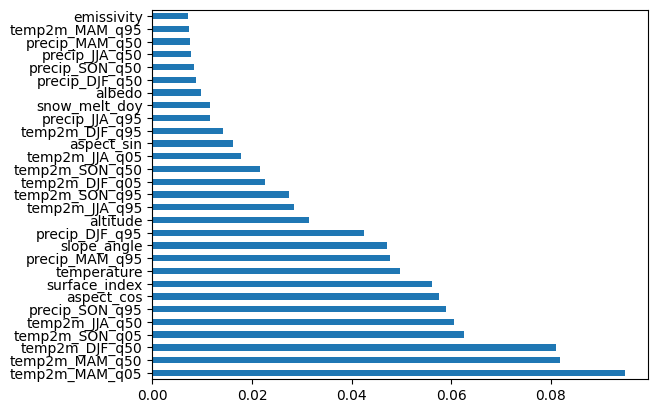

In [155]:
pd.Series(dict(zip(x.columns, modelB.feature_importances_))).sort_values(ascending=False).plot.barh()

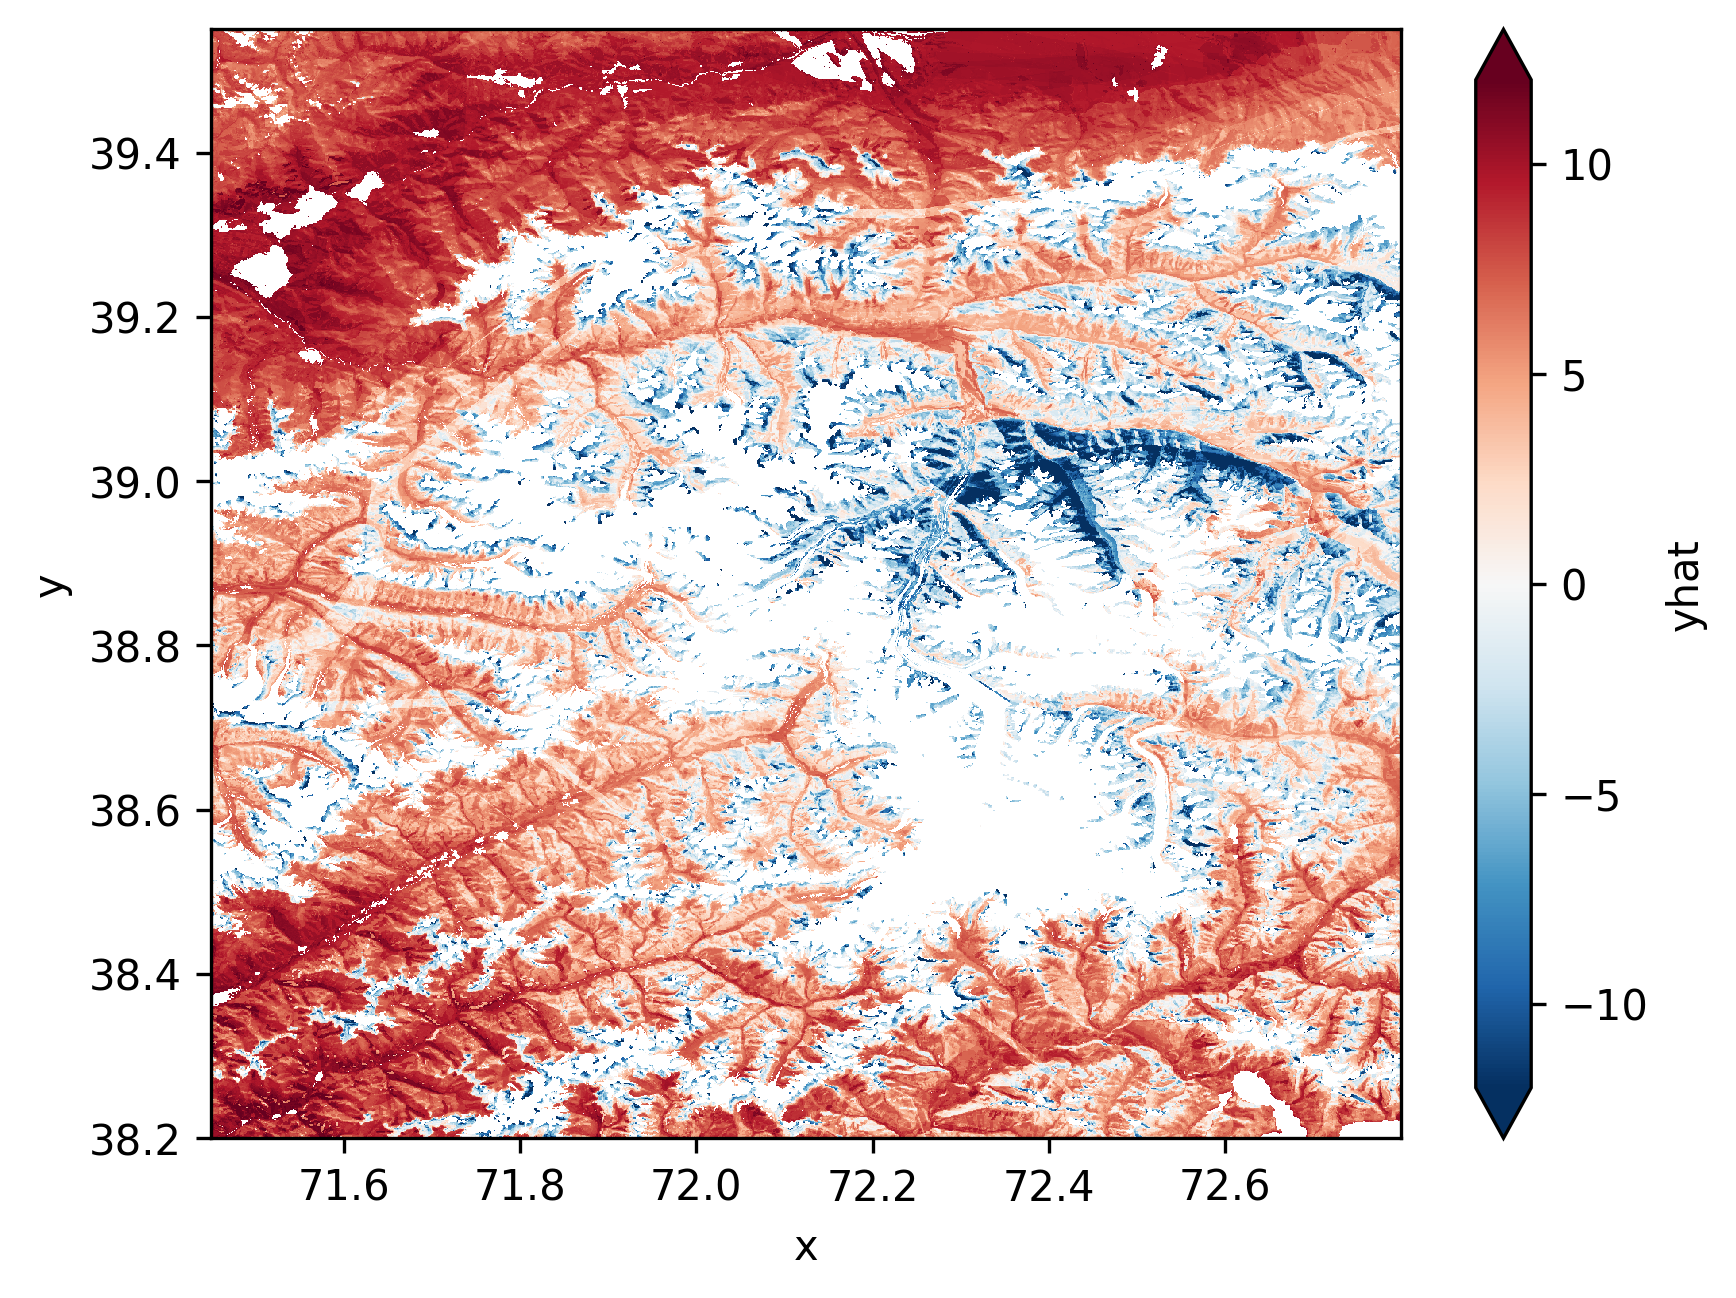

In [178]:
img = yhat.yhat.where(mask).plot.imshow(robust=True, vmin=-12, vmax=12, center=0, cmap='RdBu_r')
img.figure.set_dpi(300)

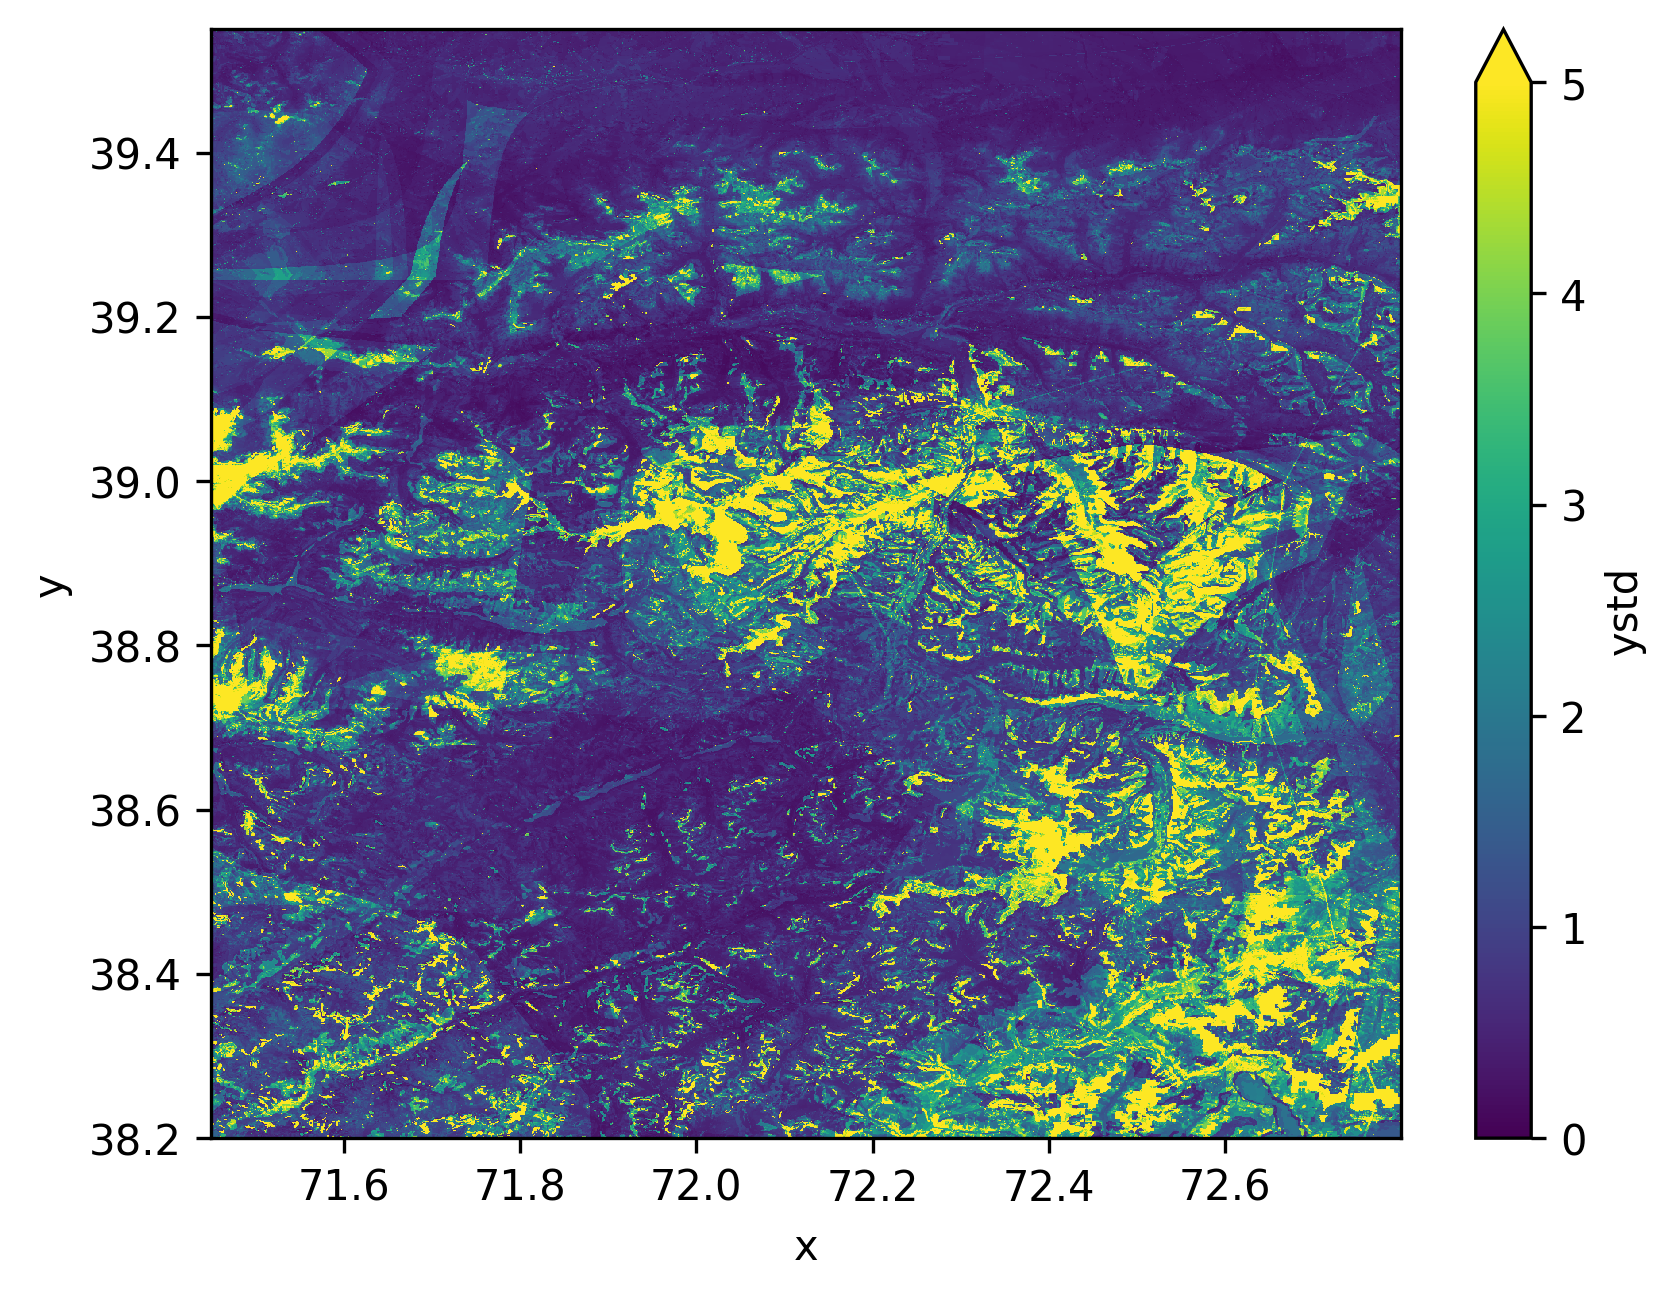

In [179]:
img = yhat.ystd.plot.imshow(robust=True, vmin=0, vmax=5)
img.figure.set_dpi(300)